In [1]:
import numpy as np
import timeit
import viscid
import os
from scipy.special import iv

argsdict=viscid.argsdict
from scipy.linalg import eig
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

import matplotlib.pyplot as plt
import json
colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

s=5
s2=0.2
admax=5.0
dfreq=10.0
eta=1E-6
argsdict['dim']=2
argsdict['Nx']=3
argsdict['Ny']=3
argsdict['Nt']=3
argsdict['k1x']=np.pi*s
argsdict['k1y']=0
argsdict['k2x']=-np.pi*s/2
argsdict['k2y']=3**0.5*s/2*np.pi
argsdict['h0']=1.0*s2
argsdict['As']=0.8*s2
num=50

argsdict['k1x']=np.pi*s
argsdict['k1y']=0
argsdict['k2x']=-np.pi*s/2
argsdict['k2y']=3**0.5*s/2*np.pi
kxs1=np.arange(1,num+1)/num*argsdict['k1x']/2
kys1=np.arange(1,num+1)/num*0
kxs2=argsdict['k1x']/2+np.arange(1,num+1)/num*((2*argsdict['k1x'] + argsdict['k2x'])/3 - argsdict['k1x']/2)
kys2=argsdict['k1y']/2+np.arange(1,num+1)/num*((2*argsdict['k1y'] + argsdict['k2y'])/3 - argsdict['k1y']/2)
kxs3=np.arange(1,num)/num*((2*argsdict['k1x'] + argsdict['k2x'])/3)
kys3=np.arange(1,num)/num*((2*argsdict['k1y'] + argsdict['k2y'])/3)
ks=np.concatenate([np.transpose([kxs1[-20::4],kys1[-20::4]]),np.transpose([kxs2[::8],kys2[::8]])])
k0=kxs1[-20]

argsdict['rho']=1.0
argsdict['sigma']=20
argsdict['mu']=20/100

Fluid depth in cm

In [2]:
argsdict['h0']

0.2

Substrate amplitude in cm

In [3]:
argsdict['As']

0.16000000000000003

Substrate wavelength in cm

In [4]:
2*np.pi/argsdict['k1x']

0.4

### Viscid instability boundary

In [5]:
argsdict['ad']=0
argsdict['kx']=k0
argsdict['ky']=0
argsdict['verbose']=1
argsdict['dsmin']=1E-4


def mat0(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-argsdict['ad']*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat3(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

def mat(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-ad*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat2(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

Find the starting critical eigenvalues and eigenvectors by continuing the driving amplitude and finding the critical value at fixed frequency and wavenumber

[19.22991394 51.98453847]
n=0 dv=1.485464e-01 dw=6.800219e-01 dl=1.282892e-01
n=1 dv=6.582478e-02 dw=1.988501e-03 dl=2.411966e-01
n=2 dv=4.034724e-02 dw=1.469228e-02 dl=4.799268e-01
n=3 dv=1.077350e-01 dw=1.554853e-02 dl=2.540641e-01
n=4 dv=1.127104e-01 dw=1.412887e-02 dl=7.613951e-02
n=5 dv=3.529687e-02 dw=7.254858e-03 dl=4.942784e-02
n=6 dv=1.272863e-02 dw=1.323290e-03 dl=1.352660e-02
n=7 dv=1.177947e-03 dw=1.074284e-04 dl=1.071475e-03
n=8 dv=5.976290e-05 dw=1.819086e-05 dl=1.914018e-04
n=9 dv=1.608155e-05 dw=5.348234e-06 dl=4.402042e-05
19.22991393533841 (17.53671085366894+7.889723648615533j)
newdir=(-0.000,-0.000,1.000)
step=0 ds=5.000000e-02 ad=0.000000 lambda=55.093202+i24.786298 dir=(-0.000, -0.000, 1.000)
ds=5.000e-02 ad=0.049978 lambda=55.121180+24.785737i stp=(0.560,-0.011,1.000) mstp=1.460e-01
step=1 ds=5.000000e-02 ad=0.049978 lambda=55.121180+i24.785737 dir=(0.488, -0.010, 0.872)
ds=7.500e-02 ad=0.081006 lambda=55.168274+24.785758i stp=(0.942,0.000,0.621) mstp=1.264e-01
st

ds=7.499e-02 ad=0.263264 lambda=55.951509+24.786250i stp=(0.990,0.004,0.144) mstp=3.774e-04
step=29 ds=7.498534e-02 ad=0.263264 lambda=55.951509+i24.786250 dir=(0.990, 0.004, 0.144)
ds=1.125e-01 ad=0.273459 lambda=56.026712+24.786531i stp=(1.003,0.004,0.136) mstp=4.614e-05
step=30 ds=1.124780e-01 ad=0.273459 lambda=56.026712+i24.786531 dir=(0.991, 0.004, 0.134)
Convergence failure!
n=11 ds=7.498e-02 dv=1.501e-02 dlambda=4.682e-03 dmu=2.204e-02 stp=(3.455,1.253,0.422) mstp=2.144e-01
step=30 ds=7.497846e-02 ad=0.273459 lambda=56.026712+i24.786531 dir=(0.991, 0.004, 0.134)
Convergence failure!
n=9 ds=4.999e-02 dv=3.255e-02 dlambda=9.217e-03 dmu=4.811e-02 stp=(8.890,0.334,1.015) mstp=7.055e-03
step=30 ds=4.998610e-02 ad=0.273459 lambda=56.026712+i24.786531 dir=(0.991, 0.004, 0.134)
Convergence failure!
n=5 ds=3.332e-02 dv=5.983e-03 dlambda=1.424e-03 dmu=8.820e-03 stp=(2.189,1.274,0.346) mstp=3.358e-01
step=30 ds=3.332407e-02 ad=0.273459 lambda=56.026712+i24.786531 dir=(0.991, 0.004, 0.134)

Convergence failure!
n=19 ds=3.330e-02 dv=5.177e-01 dlambda=1.009e+00 dmu=9.531e-01 stp=(-808.255,-57615.481,-293.312) mstp=5.762e+04
step=57 ds=3.329981e-02 ad=0.411751 lambda=57.619443+i24.787046 dir=(0.998, -0.014, 0.055)
ds=3.330e-02 ad=0.413667 lambda=57.652363+24.787508i stp=(0.989,0.014,0.058) mstp=4.004e-04
step=58 ds=3.329981e-02 ad=0.413667 lambda=57.652363+i24.787508 dir=(0.998, 0.014, 0.058)
ds=4.995e-02 ad=0.415492 lambda=57.685055+24.787860i stp=(0.982,0.011,0.055) mstp=8.028e-06
step=59 ds=4.994971e-02 ad=0.415492 lambda=57.685055+i24.787860 dir=(0.997, -0.028, 0.066)
Convergence failure!
n=7 ds=3.329e-02 dv=6.144e-03 dlambda=3.128e-03 dmu=1.904e-02 stp=(4.647,1.504,0.457) mstp=2.819e-01
step=59 ds=3.328935e-02 ad=0.415492 lambda=57.685055+i24.787860 dir=(0.997, -0.028, 0.066)
Convergence failure!
n=14 ds=2.219e-02 dv=5.203e-02 dlambda=1.821e-02 dmu=3.409e-02 stp=(38.268,-17.357,1.526) mstp=3.299e+00
step=59 ds=2.219040e-02 ad=0.415492 lambda=57.685055+i24.787860 dir=(0.

ds=3.322e-02 ad=0.441278 lambda=58.225004+24.788416i stp=(1.011,-0.008,0.043) mstp=5.016e-04
step=87 ds=3.322084e-02 ad=0.441278 lambda=58.225004+i24.788416 dir=(0.999, -0.008, 0.043)
ds=4.983e-02 ad=0.442606 lambda=58.257718+24.787260i stp=(0.985,-0.035,0.040) mstp=3.729e-04
step=88 ds=4.983127e-02 ad=0.442606 lambda=58.257718+i24.787260 dir=(0.999, -0.035, 0.041)
ds=4.983e-02 ad=0.444681 lambda=58.309274+24.788157i stp=(1.035,0.018,0.042) mstp=1.436e-03
step=89 ds=4.983127e-02 ad=0.444681 lambda=58.309274+i24.788157 dir=(0.999, 0.017, 0.040)
ds=7.475e-02 ad=0.446668 lambda=58.360726+24.787198i stp=(1.033,-0.019,0.040) mstp=6.709e-04
step=90 ds=7.474690e-02 ad=0.446668 lambda=58.360726+i24.787198 dir=(0.999, -0.019, 0.039)
ds=7.475e-02 ad=0.449499 lambda=58.436310+24.788314i stp=(1.011,0.015,0.038) mstp=5.640e-04
step=91 ds=7.474690e-02 ad=0.449499 lambda=58.436310+i24.788314 dir=(0.999, 0.015, 0.037)
Convergence failure!
n=5 ds=4.983e-02 dv=1.057e-02 dlambda=3.950e-03 dmu=4.914e-03 s

Convergence failure!
n=15 ds=2.908e-03 dv=9.569e-02 dlambda=2.310e-02 dmu=3.376e-02 stp=(152.711,313.819,11.746) mstp=2.841e+00
step=113 ds=2.908229e-03 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.319, 0.947, 0.042)
Convergence failure!
n=19 ds=1.938e-03 dv=1.680e-02 dlambda=5.806e-03 dmu=7.149e-03 stp=(126.741,-20.510,3.480) mstp=1.072e+02
step=113 ds=1.938468e-03 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.319, 0.947, 0.042)
Convergence failure!
n=19 ds=1.292e-03 dv=1.273e-03 dlambda=4.605e-04 dmu=6.247e-04 stp=(-14.953,-0.917,-0.428) mstp=2.065e+01
step=113 ds=1.292272e-03 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.319, 0.947, 0.042)
Convergence failure!
n=19 ds=8.611e-04 dv=5.568e-03 dlambda=1.871e-03 dmu=3.313e-03 stp=(58.713,74.620,3.802) mstp=5.468e+00
Minimum step!


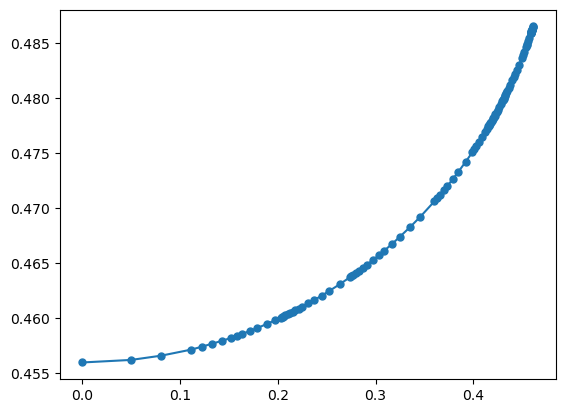

113 0.46105236513426023 (58.7832044836754+24.795030139100923j)
step=0 ds=5.000000e-02 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.947, -0.319, 0.085)
Convergence failure!
n=3 ds=3.333e-02 dv=4.919e-01 dlambda=9.373e-02 dmu=4.726e-01 stp=(-85.706,-69.423,-9.501) mstp=1.705e+02
step=0 ds=3.333333e-02 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.947, -0.319, 0.085)
Convergence failure!
n=4 ds=2.222e-02 dv=9.916e-02 dlambda=2.971e-02 dmu=6.124e-04 stp=(51.289,-31.739,0.107) mstp=1.614e+00
step=0 ds=2.222222e-02 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.947, -0.319, 0.085)
Convergence failure!
n=3 ds=1.481e-02 dv=8.843e-03 dlambda=4.164e-03 dmu=5.462e-03 stp=(14.491,-2.063,0.416) mstp=2.308e-01
step=0 ds=1.481481e-02 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.947, -0.319, 0.085)
Convergence failure!
n=3 ds=9.877e-03 dv=3.426e-01 dlambda=2.888e-01 dmu=6.191e-01 stp=(84.326,1373.678,-173.685) mstp=1.761e+03
step=0 ds=9.876543e-03 ad=0.461052 lambda=58.783204+i24.795030 dir=(0.94

/home/zack/viscidfaraday/viscid.py:34: RuntimeWarning: overflow encountered in exp
  EpOmega=np.exp((argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['h0'])
/home/zack/viscidfaraday/viscid.py:41: RuntimeWarning: invalid value encountered in multiply
  Ctilde = (EmOmega * iv(ms-mps, (argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['As']*0.5) * iv(ns-nps, (argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['As']*0.5) + EpOmega * iv(ms-mps, -(argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['As']*0.5) * iv(ns-nps, -(argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['As']*0.5))
/home/zack/viscidfaraday/viscid.py:42: RuntimeWarning: invalid value encountered in multiply
  Stilde = (- EmOmega * iv(ms-mps, (argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['As']*0.5) * iv(ns-nps, (argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['As']*0.5) + EpOmega * iv(ms-mps, -(argsdict['rho']/argsdict['mu']*Omega)**0.5*argsdict['As']*0.5) * iv(ns-nps, -(argsdict['rho']/argsdict['mu']*Ome

stopped early for exception array must not contain infs or NaNs
n=0 dv=2.246872e-01 dw=6.716426e-01 dl=2.264255e-01
n=1 dv=9.973533e-02 dw=3.121296e-02 dl=3.540885e-02
n=2 dv=3.786636e-02 dw=9.619325e-03 dl=3.301844e-02
n=3 dv=4.167209e-03 dw=2.945554e-03 dl=9.410171e-04
n=4 dv=2.578092e-04 dw=3.175958e-04 dl=9.473254e-05
51.98453846787704 (52.92505159985037+15.400757686804162j)
newdir=(-0.000,-0.000,0.997)
step=0 ds=5.000000e-02 ad=0.000000 lambda=166.268953+i48.382907 dir=(-0.000, -0.000, 0.997)
ds=5.000e-02 ad=0.049849 lambda=166.184498+48.382857i stp=(-1.689,-0.001,0.997) mstp=9.629e-01
step=1 ds=5.000000e-02 ad=0.049849 lambda=166.184498+i48.382857 dir=(-0.861, -0.001, 0.508)
ds=7.500e-02 ad=0.062770 lambda=166.134034+48.382905i stp=(-1.009,0.001,0.258) mstp=4.148e-02
step=2 ds=7.500000e-02 ad=0.062770 lambda=166.134034+i48.382905 dir=(-0.969, 0.001, 0.248)
ds=7.500e-02 ad=0.077554 lambda=166.060349+48.382983i stp=(-0.982,0.001,0.197) mstp=1.397e-03
step=3 ds=7.500000e-02 ad=0.077

In [ ]:
argsdict['kx']=k0
argsdict['ky']=0
F,G=viscid.inviscid_mat_undriven(argsdict)
Ginv=np.linalg.inv(G)
evals,revecs,levecs=eig(Ginv.dot(F).astype(complex),right=True,left=True)
order=np.argsort(np.real(evals))
#we use an initial driving frequency of 90% of the inviscid resonant frequency because the viscid resonances are smaller
freq0s=np.real(0.9*evals[order[:2]]**0.5/(2*np.pi/2)) 
print(freq0s)

F,G=viscid.inviscid_mat_undriven(argsdict)
Ginv=np.linalg.inv(G)
evals,revecs,levecs=eig(Ginv.dot(F).astype(complex),right=True,left=True)
order=np.argsort(evals)

argsdict['verbose']=1
argsdict['lambdamax']=np.inf
ds=5E-2
dsmax=5E-1
argsdict['itmax']=20
argsdict['ds']=ds
argsdict['dsmax']=dsmax
argsdict['dsmin']=1E-3
argsdict['epsl']=1E-4
argsdict['epsu']=1E-2
argsdict['epstp']=5E0

ads01=[]
ads02=[]
ads03=[]
vs01=[]
vs02=[]
vs03=[]
ws01=[]
ws02=[]
ws03=[]
omegas01=[]
omegas02=[]
omegas03=[]

load=False
overwrite=True

start=timeit.default_timer()
for j in range(2):
    if not os.path.exists('data/experiment/%iads01.npy'%(j)) or not load:
        omega=evals[order[j]]**0.5+1j*0
        E,F=viscid.viscid_mat2d(omega,argsdict)

        v=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        w=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        v[2,argsdict['Nt']]=(revecs[:,order[j]].dot(Ginv)/np.linalg.norm(revecs[:,order[j]].dot(Ginv))).reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        w[2,argsdict['Nt']]=levecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        v=v.ravel()
        w=w.ravel()

        freq0=freq0s[j]
        omega=evals[order[j]]**0.5+1j*0
        argsdict['freq']=freq0
        argsdict['ad']=0

        lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
        kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
        kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
        kappa = (kappax**2+kappay**2)**0.5
        kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
        kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
        S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
        C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

        #right preconditioner
        shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
        shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
        A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
        argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

        argsdict['precondition_axes']=((6,7),(0,1))
        argsdict['precondition_order']=(0,1,2,3,4,5,6,7)


        #starting frequency and driving
        omegas,vs,ws=viscid.rayleigh_mat(omega,v,np.conjugate(w),mat0,argsdict)
        omega0=omegas[-1]
        v0=vs[-1]
        w0=ws[-1]
        print(freq0,omegas[-1]/np.pi)
        argsdict['par']='ad'
        argsdict['pari']=0
        argsdict['parf']=admax
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3)
        omegas01=omegas01+[omegas]
        vs01=vs01+[vs]
        ws01=ws01+[ws]
        ads01=ads01+[pars]
        plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0], marker='o', ms=5)
        plt.show()
        
        ind=np.argmax(pars)
        fomega=interp1d(np.arange(len(omegas)),omegas,kind='cubic')
        fv=interp1d(np.arange(len(omegas)),np.array(vs).T,kind='cubic')
        fw=interp1d(np.arange(len(omegas)),np.array(ws).T,kind='cubic')
        fpar=interp1d(np.arange(len(omegas)),pars,kind='cubic')
        fdir=interp1d(np.arange(len(omegas)),np.array(dirs).T,kind='cubic')

        if ind<len(pars)-3:
            if pars[ind-2]<pars[ind] and pars[ind+2]<pars[ind]:
                find=minimize_scalar(lambda x: -fpar(x),bracket=(ind-1,ind+1)).x
            else:
                find=minimize_scalar(lambda x: fpar(x),bracket=(ind-1,ind+1)).x
        else:
            find=ind
            
        omega0=complex(fomega(find))
        v0=fv(find)
        w0=fw(find)
        dir0=fdir(find)
        s=3*(2*argsdict['Nt']+1)*(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1)
        newdir=np.zeros(dir0.shape)
        newdir[:s]=dir0[s:2*s]
        newdir[s:2*s]=-dir0[:s]
        newdir[2*s]=dir0[2*s+1]
        newdir[2*s+1]=-dir0[2*s]
        newdir[2*s+2]=2*dir0[2*s+2]
        dir0=newdir
        argsdict['ad']=fpar(find)
        print(ind,argsdict['ad'],omega0)
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0)
        omegas02=omegas02+[omegas]
        vs02=vs02+[vs]
        ws02=ws02+[ws]
        ads02=ads02+[pars]
        argsdict['ds']=-argsdict['ds']
        argsdict['ad']=fpar(find)
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0)
        argsdict['ds']=-argsdict['ds']
        omegas03=omegas03+[omegas]
        vs03=vs03+[vs]
        ws03=ws03+[ws]
        ads03=ads03+[pars]

        if overwrite:
            np.save('data/experiment/%iomegas01.npy'%(j),omegas01[j])
            np.save('data/experiment/%iads01.npy'%(j),ads01[j])
            np.save('data/experiment/%ivs01.npy'%(j),vs01[j])
            np.save('data/experiment/%iws01.npy'%(j),ws01[j])

            np.save('data/experiment/%iomegas02.npy'%(j),omegas02[j])
            np.save('data/experiment/%iads02.npy'%(j),ads02[j])
            np.save('data/experiment/%ivs02.npy'%(j),vs02[j])
            np.save('data/experiment/%iws02.npy'%(j),ws02[j])

            np.save('data/experiment/%iomegas03.npy'%(j),omegas03[j])
            np.save('data/experiment/%iads03.npy'%(j),ads03[j])
            np.save('data/experiment/%ivs03.npy'%(j),vs03[j])
            np.save('data/experiment/%iws03.npy'%(j),ws03[j])
    else:
        omegas01=omegas01+[np.load('data/experiment/%iomegas01.npy'%(j))]
        ads01=ads01+[np.load('data/experiment/%iads01.npy'%(j))]
        vs01=vs01+[np.load('data/experiment/%ivs01.npy'%(j))]
        ws01=ws01+[np.load('data/experiment/%iws01.npy'%(j))]

        omegas02=omegas02+[np.load('data/experiment/%iomegas02.npy'%(j))]
        ads02=ads02+[np.load('data/experiment/%iads02.npy'%(j))]
        vs02=vs02+[np.load('data/experiment/%ivs02.npy'%(j))]
        ws02=ws02+[np.load('data/experiment/%iws02.npy'%(j))]

        omegas03=omegas03+[np.load('data/experiment/%iomegas03.npy'%(j))]
        ads03=ads03+[np.load('data/experiment/%iads03.npy'%(j))]
        vs03=vs03+[np.load('data/experiment/%ivs03.npy'%(j))]
        ws03=ws03+[np.load('data/experiment/%iws03.npy'%(j))]


stop=timeit.default_timer()
print(stop-start)

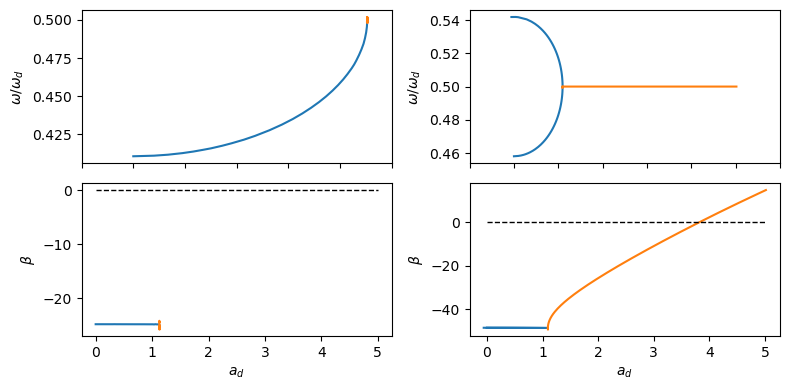

[(2.772998193636575+1.2003075740866663e-05j), (3.824882219985426+1.1304453944590693e-06j)]


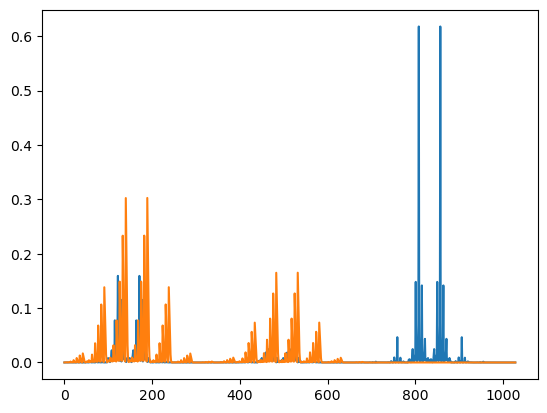

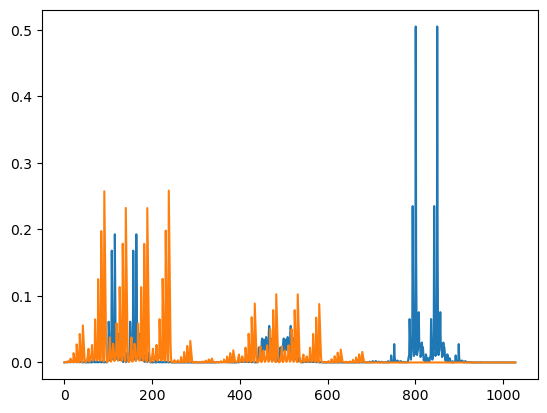

In [10]:
ad0s=[]
vn0s=[]
wn0s=[]
argsdict['epsu']=1E-3

for j in range(2):
    ind=np.argmin(np.abs(np.imag(omegas02[j])))
    argsdict['freq']=freq0s[j]
    ads,vs,ws=viscid.rayleigh_mat(ads02[j][ind],vs02[j][ind],ws02[j][ind],mat,argsdict,mat2)
    ad0s=ad0s+[ads[-1]]
    vn0s=vn0s+[vs[-1]]
    wn0s=wn0s+[ws[-1]]
    
plt.subplots(2,2,figsize=(8,4))

for j in range(2):
    plt.subplot(2,2,j+1)
    plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0])
    plt.plot(ads02[j],np.real(omegas02[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.plot(ads03[j],np.real(omegas03[j])/(2*np.pi*freq0s[j]),c=colors[1])

    plt.gca().set_xticks(plt.gca().get_xticks(),['']*len(plt.gca().get_xticks()))
    plt.ylabel(r'$\omega/\omega_d$')

    plt.subplot(2,2,j+3)
    plt.plot(ads01[j],-np.imag(omegas01[j]),c=colors[0])
    plt.plot(ads02[j],-np.imag(omegas02[j]),c=colors[1])
    plt.plot(ads03[j],-np.imag(omegas03[j]),c=colors[1])
    plt.plot([0,admax],[0,0],ls='--',color='black',lw=1)
    plt.ylabel(r'$\beta$')
    plt.xlabel('$a_d$')


plt.tight_layout()
plt.show()
print(ad0s)
for j in range(2):
    plt.plot(np.abs(vn0s[j]))
    plt.plot(np.abs(wn0s[j]))
    plt.show()

[[4.86946861 0.        ]]
1
0 21.366571039264898 4.869468613064179 0.0
stopped early for exception array must not contain infs or NaNs
stopped early for exception array must not contain infs or NaNs
20.873858276867686 21.860358375028998 20.873858276867686 (2.6880606368168865-7.352713974927974e-06j)


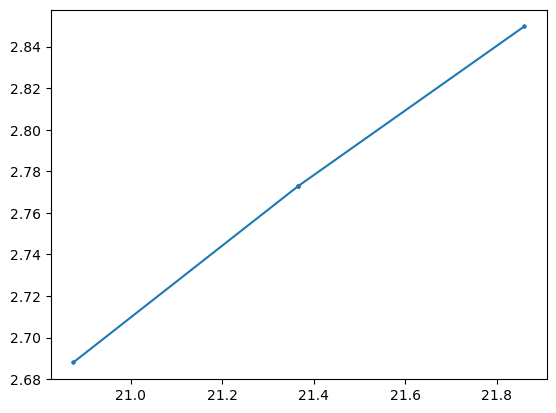

20.502633492986206
0 57.76059829764115 4.869468613064179 0.0
47.75894706853027 68.24662398328968 52.75422626480868 (3.614965864091316-4.6975280420900394e-07j)


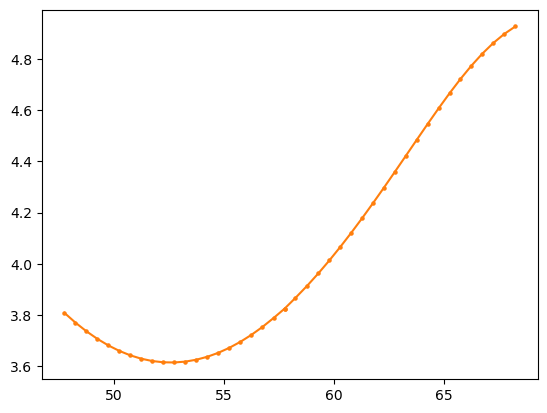

77.6418146030046


In [12]:
start=timeit.default_timer()
adssweep=[]
freqsweep=[]
vssweep=[]
wssweep=[]
dirsweep=[]
dssweep=[]
argsdict['verbose']=0
argsdict['lambdamax']=admax

ds=5E-1
argsdict['dsmax']=ds
argsdict['ds']=ds/10
argsdict['dsmin']=1E-3

argsdict['epsu']=1E-2
argsdict['epsl']=1E-3
argsdict['dmu_fd']=1E-2
argsdict['epstp']=np.inf
argsdict['epstp']=5E0
argsdict['epdir']=np.inf
argsdict['thu']=1E-3
argsdict['itmax']=10

# ks=np.concatenate([np.transpose([kxs1[-20::4],kys1[-20::4]]),np.transpose([kxs2[::8],kys2[::8]])])
ks=ks[:1]

print(ks)
print(len(ks))
overwrite=True
load=False

l=0
for j in range(2):
    ad0=ad0s[j]
    vs0=vn0s[j]
    ws0=wn0s[j]
    freq0=freq0s[j]
    
    argsdict['freq']=freq0
    argsdict['kx']=ks[0][0]
    argsdict['ky']=ks[0][1]
    
    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
    argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

    for i in range(len(ks)):
        if not os.path.exists('data/experiment/%iads.npy'%(l)) or not load:
            kx=ks[i][0]
            ky=ks[i][1]

            print(i,freq0,kx,ky)
            argsdict['freq']=freq0
            if(argsdict['kx']!=kx):
                argsdict['par']='kx'
                argsdict['pari']=np.min([kx,argsdict['kx']])
                argsdict['parf']=np.max([kx,argsdict['kx']])

                argsdict['ds']=np.sign(kx-argsdict['kx'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['kx']=kx
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]
            if(argsdict['ky']!=ky):
                argsdict['par']='ky'
                argsdict['pari']=np.min([ky,argsdict['ky']])
                argsdict['parf']=np.max([ky,argsdict['ky']])

                argsdict['ds']=np.sign(ky-argsdict['ky'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['ky']=ky
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]

            lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
            kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
            kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
            kappa = (kappax**2+kappay**2)**0.5
            kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
            kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
            S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
            C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

            #right preconditioner
            shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
            shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
            A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
            argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

            argsdict['precondition_axes']=((6,7),(0,1))
            argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

            argsdict['freq']=freq0
            argsdict['par']='freq'
            argsdict['pari']=freq0-dfreq
            argsdict['parf']=freq0+dfreq

            argsdict['ds']=ds
            np.random.seed(l)
            ads2,vs2,ws2,pars2,dirs2,dss2=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
            argsdict['freq']=freq0        
            argsdict['ds']=-ds
            np.random.seed(l)
            ads3,vs3,ws3,pars3,dirs3,dss3=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2) 
            

            freqsweep=freqsweep+[np.flip(pars3).tolist()+pars2]
            adssweep=adssweep+[np.flip(ads3).tolist()+ads2]
            vssweep=vssweep+[np.flip(vs3,axis=0).tolist()+vs2]
            wssweep=wssweep+[np.flip(ws3,axis=0).tolist()+ws2]
            dirsweep=dirsweep+[np.flip(dirs3,axis=0).tolist()+dirs2]
            dssweep=dssweep+[np.flip(dss3,axis=0).tolist()+dss2]
            if overwrite:
                np.save('data/experiment/%iads.npy'%(l),adssweep[l])
                np.save('data/experiment/%ivs.npy'%(l),vssweep[l])
                np.save('data/experiment/%iws.npy'%(l),wssweep[l])
                np.save('data/experiment/%ifreqs.npy'%(l),freqsweep[l])
                np.save('data/experiment/%idirs.npy'%(l),dirsweep[l])
                np.save('data/experiment/%idss.npy'%(l),dssweep[l])

        else:
            adssweep=adssweep+[np.load('data/experiment/%iads.npy'%(l))]
            vssweep=vssweep+[np.load('data/experiment/%ivs.npy'%(l))]
            wssweep=wssweep+[np.load('data/experiment/%iws.npy'%(l))]
            freqsweep=freqsweep+[np.load('data/experiment/%ifreqs.npy'%(l))]
            dirsweep=dirsweep+[np.load('data/experiment/%idirs.npy'%(l))]
            dssweep=dssweep+[np.load('data/experiment/%idss.npy'%(l))]
            
        ind=np.argmin(np.abs(adssweep[-1]))
        ad0=adssweep[-1][ind]
        vs0=np.array(vssweep[-1][ind])
        ws0=np.array(wssweep[-1][ind])
        freq0=freqsweep[-1][ind]
        print(freqsweep[-1][0],freqsweep[-1][-1],freq0,ad0)
        
        
        plt.plot(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[l%len(colors)])
        plt.scatter(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[l%len(colors)],s=5)
        plt.show() 
        
        l=l+1

        stop=timeit.default_timer()
        print(stop-start)


In [ ]:
plt.figure(figsize=(8,4))
for i in range(len(ks)):
    inds=np.where(np.abs(np.imag(adssweep[i]))<1E-4)[0]
    plt.plot(np.array(freqsweep[i])[inds],np.abs(np.real(adssweep[i]))[inds],c=colors[(i-4)%len(colors)])
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.ylim(0,20.0)
plt.tight_layout()

for i in range(len(ks)):
    inds=np.where(np.abs(np.imag(adssweep[i+len(ks)]))<1E-4)[0]
    plt.plot(np.array(freqsweep[i+len(ks)])[inds],np.abs(np.real(adssweep[i+len(ks)]))[inds],c=colors[(i-4)%len(colors)],label='$k_x=%.3f, ky=%.3f$'%(ks[i][0],ks[i][1]))


dat=np.loadtxt('data/experiment/t1/t1.txt')
plt.plot(dat[:,2],dat[:,1],'bx',markersize=2.0)

plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.ylim(0,admax)
plt.tight_layout()
plt.show

In [ ]:
plt.figure(figsize=(8,4))
for i in range(len(ks)):
    plt.plot(np.array(freqsweep[i]),np.abs(np.imag(adssweep[i])),c=colors[(i-4)%len(colors)])
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
# plt.ylim(0,20.0)
plt.tight_layout()

for i in range(len(ks)):
    plt.plot(np.array(freqsweep[i+len(ks)]),np.abs(np.imag(adssweep[i+len(ks)])),c=colors[(i-4)%len(colors)],label='$k_x=%.3f, ky=%.3f$'%(ks[i][0],ks[i][1]))


plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$Im(a_d)$')
# plt.ylim(0,admax)
plt.yscale('log')
plt.tight_layout()
plt.show